In [ ]:
import glob
import os
import pickle
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append("../../src")

from util import *

In [6]:
df = pd.read_csv('../../data/processed/tdc/HTS/3_HIV_date.tsv', header=0, sep='\t', names=['smiles', 'tox', 'year'])
df = df.sort_values(by='year', ascending=True).reset_index(drop=True)
print(len(df))

5715


In [7]:
df

,smiles,tox,year
0,c1cnc2c(c1)ccc1cccnc12,0,1973.025
1,Clc1nc(Cl)nc(Nc2ccccc2Cl)n1,0,1973.025
2,O=C1CC(=O)Nc2ccccc2N1,0,1973.044
3,NCC1CCC(C(=O)O)CC1,0,1973.044
4,O=C1OC2(c3ccc(O)cc3Oc3cc(O)ccc32)c2ccccc21,0,1973.044
...,...,...,...
5710,N#Cc1c2c(c(Nc3ccc(Cl)cc3)n3c1nc1ccccc13)CCCC2,0,2023.819
5711,C=CCCC[PH](c1ccccc1)(c1ccccc1)c1ccccc1,0,2023.852
5712,Clc1cc2nsnc2c(Cl)n1,0,2023.877
5713,CCCCn1c2c(c3ccccc3c1=O)C(=O)c1ccccc1-2,0,2023.929


In [9]:
s = pickle_load('/workspace/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/3_HIV/s.pkl')
t = pickle_load('/workspace/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/3_HIV/t.pkl')

In [11]:
import numpy as np
def lsh_forest_purity(s, t, labels):
    matches = (labels[s] == labels[t])
    purity = np.sum(matches) / len(matches)
    return purity

In [20]:
real = lsh_forest_purity(s, t, df['tox'].values)

In [13]:
pos_ratio = np.sum(df['tox']) / len(df['tox'])
print(f'Positive ratio in the whole dataset: {pos_ratio:.4f}')

Positive ratio in the whole dataset: 0.0322


In [ ]:
random_tox = []
num_pos = int(np.sum(df['tox']))
num_neg = len(df['tox']) - num_pos
for _ in range(num_pos):
    random_tox.append(1)
for _ in range(num_neg):
    random_tox.append(0)

rands = []
for _ in range(1000):
    np.random.shuffle(random_tox)
    rands.append(lsh_forest_purity(s, t, np.array(random_tox)))

Text(0, 0.5, 'Frequency')

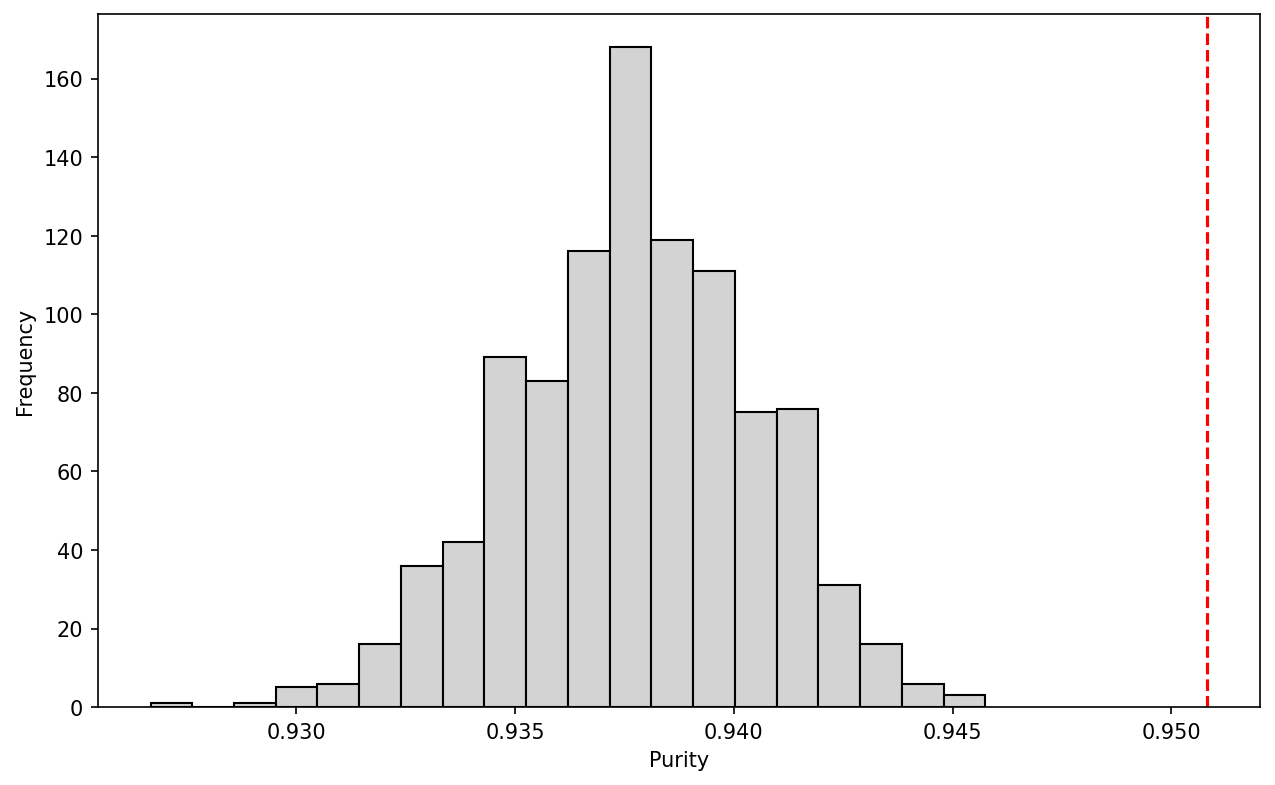

In [23]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
ax.hist(rands, bins=20, color='lightgray', edgecolor='black')
ax.axvline(x=real, color='red', linestyle='--', label='TMAP Purity')
ax.set_xlabel('Purity')
ax.set_ylabel('Frequency')

# run in all tests

In [ ]:
paths = glob.glob("../../data/processed/tdc/*/*_date.tsv")
df_details = pd.read_csv("../../data/processed/tdc/details.tsv", sep='\t', header=None)

In [32]:
tasks = {}
for i in range(len(df_details)):
    name = df_details.iloc[i, 1]
    task_type = df_details.iloc[i, 5]
    tasks[name] = task_type

classification_paths = []
for path in paths:
    task_name = os.path.basename(path).replace("_date.tsv", "")
    if tasks[task_name] != 2:
        continue
    else:
        classification_paths.append(path)

print(len(classification_paths))

33


In [ ]:
root_result_path = "../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc"
task_folders = [f for f in os.listdir(root_result_path) if os.path.isdir(os.path.join(root_result_path, f))]

results = []
num_permutations = 1000
for i in range(len(classification_paths)):
    task_name = os.path.basename(classification_paths[i]).replace('_date.tsv', '')
    output_folder_path = f"../../data/result/fig2-fig3-fig4-fig5-fig7_tmap/fig7-tdc/{task_name}"

    df = pd.read_csv(classification_paths[i], sep='\t', header=0, names=['smiles', 'tox', 'year'])
    df = df.sort_values(by='year', ascending=True).reset_index(drop=True)
    
    s = pickle_load(f'{root_result_path}/{task_name}/s.pkl')
    t = pickle_load(f'{root_result_path}/{task_name}/t.pkl')

    real = lsh_forest_purity(s, t, df['tox'].values)


    random_tox = df['tox'].tolist()
    pos_ratio = np.sum(df['tox']) / len(df['tox'])

    rands = []
    for _ in range(num_permutations):
        np.random.shuffle(random_tox)
        rands.append(lsh_forest_purity(s, t, np.array(random_tox)))
    p_value = np.mean(np.array(rands) >= real)
    results.append((task_name, real, rands, p_value, pos_ratio))

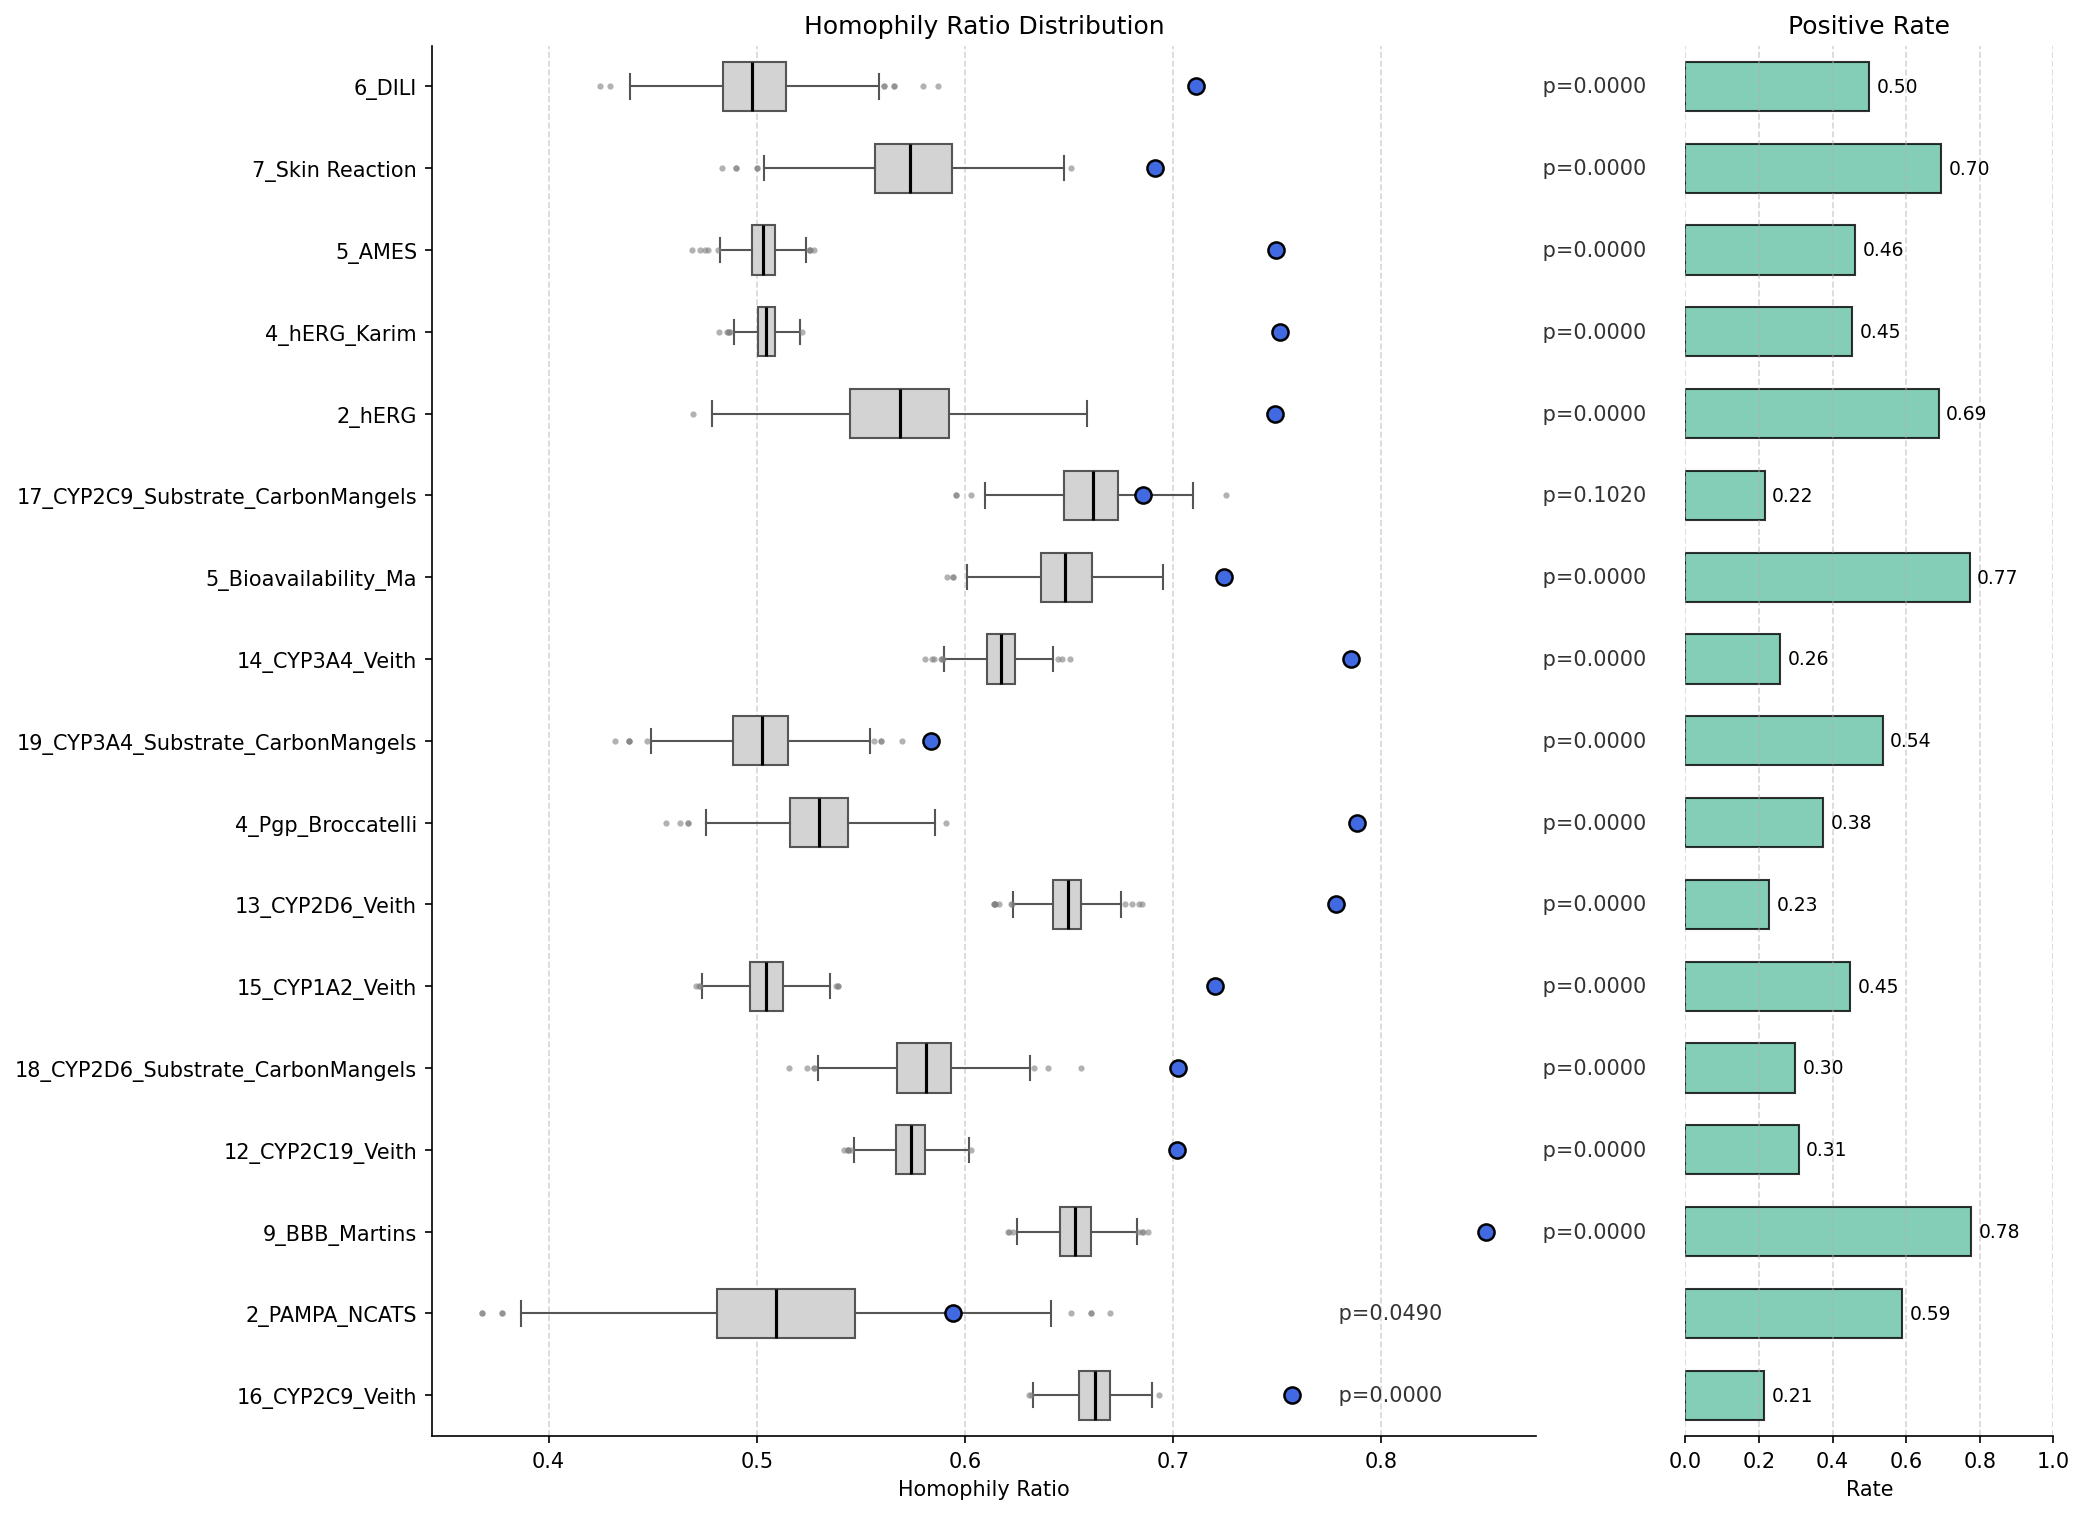

In [ ]:
result_selected = [res for res in results if res[4] >= 0.2 and res[4] <= 0.8]

rands_all = [rands for (_, _, rands, _, _) in result_selected]
labels = [task_name for (task_name, _, _, _, _) in result_selected]
reals = [real for (_, real, _, _, _) in result_selected]
p_values = [p_val for (_, _, _, p_val, _) in result_selected]
pos_ratios = [pos_ratio for (_, _, _, _, pos_ratio) in result_selected]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, len(labels) * 0.6), dpi=150, sharey=True, 
                               gridspec_kw={'width_ratios': [3, 1]})


bp = ax1.boxplot(
    rands_all,
    vert=False,
    patch_artist=True,
    widths=0.6,
    showfliers=True,
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, 
                    linestyle='none', markeredgecolor='none', alpha=0.6)
)

for patch in bp['boxes']:
    patch.set_facecolor('#D3D3D3')
    patch.set_edgecolor('#555555')
    patch.set_linewidth(1)

for element in ['whiskers', 'caps']:
    plt.setp(bp[element], color='#555555', linewidth=1)

plt.setp(bp['medians'], color='black', linewidth=1.5)

y_positions = np.arange(1, len(labels) + 1) 

for i, (real_val, p_val) in enumerate(zip(reals, p_values)):
    ax1.scatter(
        real_val, 
        y_positions[i], 
        color='#4169E1',
        s=60,             
        edgecolor='black', 
        linewidth=1.2,
        zorder=10,        
        label="Real Value" if i == 0 else None
    )
    
    x_max = ax1.get_xlim()[1]
    ax1.text(
        x_max, 
        y_positions[i], 
        f" p={p_val:.4f}", 
        va='center', ha='left', fontsize=10, color='#333333'
    )

ax1.set_title("Homophily Ratio Distribution")
ax1.set_xlabel("Homophily Ratio")
ax1.grid(axis='x', linestyle='--', alpha=0.5)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2.barh(y_positions, pos_ratios, color='#66C2A5', edgecolor='black', height=0.6, alpha=0.8)

ax2.set_title("Positive Rate")
ax2.set_xlabel("Rate")
ax2.set_xlim(0, 1.0)
ax2.grid(axis='x', linestyle='--', alpha=0.5)

for i, v in enumerate(pos_ratios):
    ax2.text(v + 0.02, y_positions[i], f"{v:.2f}", va='center', fontsize=9)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.tick_params(left=False) 

ax1.set_yticks(y_positions)
ax1.set_yticklabels(labels)

plt.tight_layout()
plt.show()